In [1]:
import tensorflow as tf
from tensorflow import keras
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam, SGD
from common_utilities import *
import matplotlib.pyplot as plt

In [26]:
def prepare_data1(data):
    #data['size'] = data['size'].astype(str)
    #data_dummies = pd.get_dummies(data, columns=['size'])
    X = data.drop(['sample', 'regulator', 'target', 'interaction', 'size'], axis=1).values
    y = data['interaction'].values
    X = np.asarray(X).astype(np.float32)
    y = np.asarray(y).astype(np.float32)
    return X, y

In [28]:
def performance_metrics1(y, y_predicted):
    tp=fp=tn=fn=0
    for i in range(len(y)):
        if y[i]==y_predicted[i]:
            if y[i]==1:
                tp+=1
            else:
                tn+=1
        else:
            if y[i]==1:
                fn+=1
            else:
                fp+=1
    precision = tp/(tp+fp) if (tp+fp)!=0 else 0
    recall = tp/(tp+fn) if (tp+fn)!=0 else 0
    structural = (tp+tn)/(tp+fp+fn+tn)
    tpr = recall
    fpr = fp/(fp+tn) if (fp+tn)!=0 else 1
    return precision, recall, structural, tpr, fpr

In [30]:
def get_performace1(test_set, y_predicted):
    test_set['predicted'] = y_predicted
    result={}
    sample = set(test_set['sample'].values)
    for sp in sample:
        network = test_set[test_set['sample']==sp]
        p,r,st, tpr, fpr = performance_metrics1(network['interaction'].values, network['predicted'].values)
        result[f'{sp}'] = {'precision':round(p, 4), 'recall':round(r,4), 'structural': round(st,4), 
                           'tpr':round(tpr, 4), 'fpr':round(fpr, 4)}
    return result

**Load training, validation, and test set**

In [3]:
training_set1 = pd.read_csv(r'C:\caocao\ANN\single_size\training\size100_5.csv', index_col=0)
training_set2 = pd.read_csv(r'C:\caocao\ANN\single_size\training\size100_10.csv', index_col=0)
training_set3 = pd.read_csv(r'C:\caocao\ANN\single_size\training\size100_15.csv', index_col=0)
training_set4 = pd.read_csv(r'C:\caocao\ANN\single_size\training\size100_20.csv', index_col=0)

In [5]:
training_set1.shape

(4950000, 107)

In [7]:
training_set1_50 = pd.read_csv(r'C:\caocao\ANN\single_size\training\size50_10.csv', index_col=0)
training_set2_50 = pd.read_csv(r'C:\caocao\ANN\single_size\training\size50_20.csv', index_col=0)

In [8]:
training_set1_50_1 = training_set1_50[training_set1_50.interaction==1]
training_set1_50_2 = training_set2_50[training_set2_50.interaction==1]

In [9]:
training_size10 = pd.read_csv(r'C:\caocao\ANN\single_size\training\size10.csv', index_col=0)
training_size10_true = training_size10[training_size10.interaction==1]

In [10]:
training_set = pd.concat([training_set1, training_set2, training_set3,training_set4, training_set1_50_1,\
                         training_set1_50_2,training_size10_true], ignore_index=True)

In [15]:
training_set.shape

(20276100, 107)

In [17]:
valid_set = pd.read_csv(r'C:\caocao\ANN\single_size\validation\size100.csv', index_col=0)
test_set = pd.read_csv(r'C:\caocao\ANN\single_size\test\size100.csv', index_col=0)

**Prepare data**

In [32]:
X_train, y_train = prepare_data1(training_set)

In [33]:
X_valid, y_valid = prepare_data1(valid_set)

In [34]:
X_test, y_test = prepare_data1(test_set)

**Build the model**

In [35]:
model = keras.models.Sequential([ 
    keras.layers.Dense(1024, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(512, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(256, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(8, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(1, activation="sigmoid")
])

#optimizer = keras.optimizers.RMSprop(lr=0.001, rho=0.9)
optimizer = SGD(clipvalue=1.0, momentum=0.9, nesterov=True)
#optimizer=Adam(learning_rate=0.01, beta_1=0.9, beta_2=0.999)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
model.compile(loss="mean_squared_error", optimizer=optimizer, metrics=['accuracy'])

C:\caocao\setup\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
history = model.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid), 
                    callbacks=[early_stopping_cb])

Epoch 1/100
633629/633629 ━━━━━━━━━━━━━━━━━━━━ 10573s 17ms/step - accuracy: 0.9559 - loss: 0.0401 - val_accuracy: 0.9748 - val_loss: 0.0246
Epoch 2/100
633629/633629 ━━━━━━━━━━━━━━━━━━━━ 13181s 21ms/step - accuracy: 0.9571 - loss: 0.0390 - val_accuracy: 0.9756 - val_loss: 0.0243
Epoch 3/100
633629/633629 ━━━━━━━━━━━━━━━━━━━━ 16093s 25ms/step - accuracy: 0.9574 - loss: 0.0388 - val_accuracy: 0.9751 - val_loss: 0.0243
Epoch 4/100
633629/633629 ━━━━━━━━━━━━━━━━━━━━ 31911s 50ms/step - accuracy: 0.9576 - loss: 0.0386 - val_accuracy: 0.9754 - val_loss: 0.0242
Epoch 5/100
633629/633629 ━━━━━━━━━━━━━━━━━━━━ 18021s 28ms/step - accuracy: 0.9577 - loss: 0.0385 - val_accuracy: 0.9765 - val_loss: 0.0232
Epoch 6/100
633629/633629 ━━━━━━━━━━━━━━━━━━━━ 19281s 30ms/step - accuracy: 0.9578 - loss: 0.0385 - val_accuracy: 0.9755 - val_loss: 0.0242
Epoch 7/100
633629/633629 ━━━━━━━━━━━━━━━━━━━━ 20581s 32ms/step - accuracy: 0.9579 - loss: 0.0384 - val_accuracy: 0.9754 - val_loss: 0.0242
Epoch 8/100
633629/6

In [41]:
model.save('model_100.h5')

(0.0, 1.0)

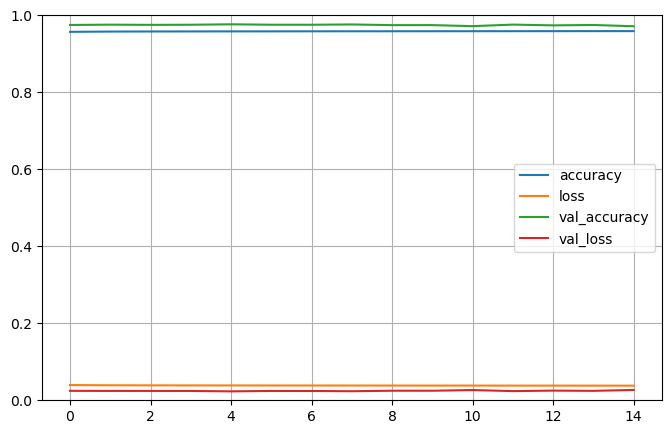

In [44]:
pd.DataFrame(history.history).plot(figsize=(8, 5)) 
plt.grid(True)
plt.gca().set_ylim(0, 1)

**Evaluate on the test set**

In [47]:
y_predicted = model.predict(X_test)

123750/123750 ━━━━━━━━━━━━━━━━━━━━ 1641s 13ms/step


**ROC curve**

In [52]:
def performance_metrics1(y, y_predicted):
    tp=fp=tn=fn=0
    for i in range(len(y)):
        if y[i]==y_predicted[i]:
            if y[i]==1:
                tp+=1
            else:
                tn+=1
        else:
            if y[i]==1:
                fn+=1
            else:
                fp+=1
    precision = tp/(tp+fp) if (tp+fp)!=0 else 0
    recall = tp/(tp+fn) if (tp+fn)!=0 else 0
    structural = (tp+tn)/(tp+fp+fn+tn)
    tpr = recall
    fpr = fp/(fp+tn) if (fp+tn)!=0 else 1
    return precision, recall, structural, tpr, fpr

In [54]:
def get_performace1(test_set, y_predicted):
    test_set['predicted'] = y_predicted
    result={}
    sample = set(test_set['sample'].values)
    for sp in sample:
        network = test_set[test_set['sample']==sp]
        p,r,st, tpr, fpr = performance_metrics1(network['interaction'].values, network['predicted'].values)
        result[f'{sp}'] = {'precision':round(p, 4), 'recall':round(r,4), 'structural': round(st,4), 
                           'tpr':round(tpr, 4), 'fpr':round(fpr, 4)}
    return result

In [56]:
thresholds = [i/100 for i in range(100, 0, -1)]
performances = []
for threshold in thresholds:
    predicted = get_round(y_predicted, threshold)
    result = get_performace1(test_set, predicted)
    performance = pd.DataFrame.from_dict(result, orient='index')
    performances.append(performance)
    performance.to_csv(fr'C:\caocao\ANN\single_size\test\performance\size100_threshold_{threshold}.csv')

In [57]:
curves_info = {i:[[],[]] for i in range(100)}
for per in performances:
    for i in range(100):
        curves_info[i][0].append(per.iloc[i, 3])
        curves_info[i][1].append(per.iloc[i, 4])

In [58]:
plt.figure(figsize=(8, 6))
plt.rcParams.update({
    'font.size': 12,              # Default font size for text
    'axes.titlesize': 20,         # Font size for axes titles
    'axes.labelsize': 15,         # Font size for x and y labels
    'xtick.labelsize': 12,        # Font size for x tick labels
    'ytick.labelsize': 12,        # Font size for y tick labels
    'legend.fontsize': 12,        # Font size for legend
    'figure.titlesize': 22        # Font size for figure title
})
plt.tick_params(axis='both',        # Apply changes to both x and y axes
                which='major',      # Apply changes to major ticks
                direction='inout',    # Ticks pointing outwards
                length=10,          # Length of ticks
                width=2           # Width of ticks
                #colors='red',       # Color of ticks
                #grid_color='black', # Color of gridlines
                #grid_alpha=0.5)     # Transparency of gridlines
               )
plt.xlim(0, 0.35)
plt.ylim(0, 0.8)
for k, v in curves_info.items():
    
    plt.plot(v[1], v[0], linewidth=3, marker='o', linestyle='dashed', color='#ff4f00')   
    plt.fill_between(v[1], v[0], color='#99ce3e', alpha=0.4)
    plt.text(0.2, 0.3, 'AUC', fontsize=14, color='#0d929a', ha='center', weight='bold')
    plt.text(0.07, 0.4, 'ROC', fontsize=14, color='#0d929a', ha='center',  weight='bold')
    plt.plot([0,v[1][-1]], [0, v[0][-1]], linewidth=3, linestyle='solid', color='#650000')
    plt.title(f'ROC curve - sample {k}')
    plt.xlabel('FP Rate')
    plt.ylabel('TP Rate')
    plt.savefig(fr'C:\caocao\ANN\single_size\test\performance\ROC\s100_{k}.png')
    plt.clf()

<Figure size 800x600 with 0 Axes>